In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from functions.funcs import *
import functions.output_functions as output 
import geopandas as gpd
import matplotlib.gridspec as gridspec
import seaborn as sns
import shapely as shp

from importlib import reload 
reload(output)

<module 'functions.output_functions' from 'C:\\FATE\\Code\\functions\\output_functions.py'>

## Analyizing Forcasts for: CMEMS, Kriging, and percistance

In [33]:
ds = pd.read_csv("saved_output/Autocorrelation_intial_speed_dif_OSCAR_CMEMS_wind2024.csv")
ds2 = pd.read_csv("./saved_output/cmems_dynamical_wind2024.csv")
ds3 = pd.read_csv("saved_output/OSCAR_2024_wind.csv")
ds4 = pd.read_csv("saved_output/No_forecast.csv")
ds5 = pd.read_csv("saved_output/climatological2024.csv")
ds6 = pd.read_csv("saved_output/combined_Percistance2024.csv")
# ds7 = pd.read_csv("saved_output/cmems_dynamical_depth4.csv")
# ds8 = pd.read_csv("saved_output/OSCAR_2024_wind.csv")
# ds9 = pd.read_csv("saved_output/cmems_dynamical2024.csv")
# ds10 = pd.read_csv("saved_output/OSCAR_2024.csv")
# ds11 = pd.read_csv("saved_output/intial_speed_dif_OSCAR_CMEMS_wind.csv")
#pts = pd.read_csv("../Data/pts_csv.csv")
ds6 = ds6.drop(columns= ["BouyID", 'speed_ms_persistence'])

# to fix persistance column names intial
ds6=ds6.rename(columns={"Latitude_true" : "lat_true", "Longitude_true": "lon_true", 
                  "Latitude_persistence": "lat_forcast",
                    "Longitude_persistence": "lon_forcast", 
                    "lead_time_hours": "leadtime" , "DateTime": "Time"})

In [34]:
#### calc Skill score based on Lui et al 2010
#1) Have to interp onto even timeseps 
#2) calc displacesment of true
#3) Calc error of Forecast
# I am writing a function to use in after grouby("...").apply(). 
def calculate_rmse(group, column = 'error_km'):
    rmse = np.sqrt((group[column]**2).mean())
    return rmse 

def interpolate_data(group):
    lead_col = 'leadtime'
    bins = np.linspace(0, 8*24, 2*24 + 1)  # every 4 hours

    g = group.copy()
    g = g.set_index(lead_col).sort_index()

    # If there are duplicate leadtime values, remove them before interpolating
    if g.index.duplicated().any():
        g = g[~g.index.duplicated(keep='first')]
    
    maxleadtime = g.index.max()
    bins_shortened = bins[bins < maxleadtime]
    new_index = pd.Index(bins_shortened, name=lead_col)

    # include existing points so interpolation has anchors, then interpolate
    combined_index = new_index.union(g.index)
    g = g.reindex(combined_index).sort_index()
    cols = ['Time','lat_true', 'lon_true','lat_forcast', 'lon_forcast']
    g = g[cols].interpolate(method='linear', limit_direction='both')

    # keep only the rows at the bin locations
    out = g.reindex(new_index).reset_index()
    return out

def dtrue(group): 
    group['dlat_true'] = group['lat_true'].diff()
    group['dlon_true'] = group['lon_true'].diff()
    return group

In [131]:
dslist = [ds, ds2,ds3,ds4,ds5,ds6]
bins = np.linspace(0,8*24,2*24+1)
skill_score = True ## False: does not interpolate (True: take a few minutes to run)

#Outputs to be plotted
ltes = []
stds = []
sss = []
dslist_notinterp = []

for i, dsi in enumerate(dslist):
    dsi['error_km'] = output.haversine_df(dsi, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
    dsi["lead_bins"] = pd.cut(dsi["leadtime"], bins, right= True)
    dslist_notinterp.append(dsi) 

    ltei = dsi.groupby("lead_bins", observed=False).apply(calculate_rmse, include_groups=False).to_numpy()
    pad = np.array([0])
    ltei  = np.concat([pad, ltei])
    ltes.append(ltei)
    
    stdi = dsi.groupby("lead_bins", observed=False)["error_km"].std()
    stdi = np.concat([pad, stdi])
    stds.append(stdi)

    if skill_score == True: 
        ##Interpolates Data onto regular intervals
        dsi = output.add_starttime(dsi)
        dsi = dsi.groupby(['BuoyID','starttime'], observed= False).apply(interpolate_data, include_groups = False).reset_index(level=['BuoyID', 'starttime']).reset_index(drop=True)
        dsi = dsi.groupby(['BuoyID','starttime'], observed= False).apply(dtrue, include_groups = False).reset_index(level=['BuoyID', 'starttime']).reset_index(drop=True)
        dsi['dlat_true_km'] = dsi['dlat_true']*110
        dsi['dlon_true_km'] =dsi['dlon_true']*110

        # Calc Error_km and RMSE of displacement 
        dsi['error_km'] = output.haversine_df(dsi, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
        dsi["lead_bins"] = pd.cut(dsi["leadtime"], bins, right= True)
        dslist_notinterp.append(dsi)

        g = dsi.groupby(['BuoyID', 'starttime'], observed=False)
        # cumsumdistance: d is row-wise, dcum is cumsum of d per group
        dsi['d']    = (dsi['dlat_true_km']**2 + dsi['dlon_true_km']**2)**(1/2)
        dsi['dcum'] = g['d'].transform('cumsum')
        # cumsumerror: cumsum of error_km per group
        dsi['error_cum'] = g['error_km'].transform('cumsum')
        # skillscore
        dsi['skillscore'] = 1- (dsi['error_km'] / dsi['dcum'])
        dsi['skillscore'] = dsi['skillscore'].clip(lower = 0)

        ss = dsi.groupby("lead_bins", observed=False)['skillscore'].mean().to_numpy()
        pad = np.array([0])
        ss  = np.concat([pad, ss])
        sss.append(ss)
        dslist[i] = dsi


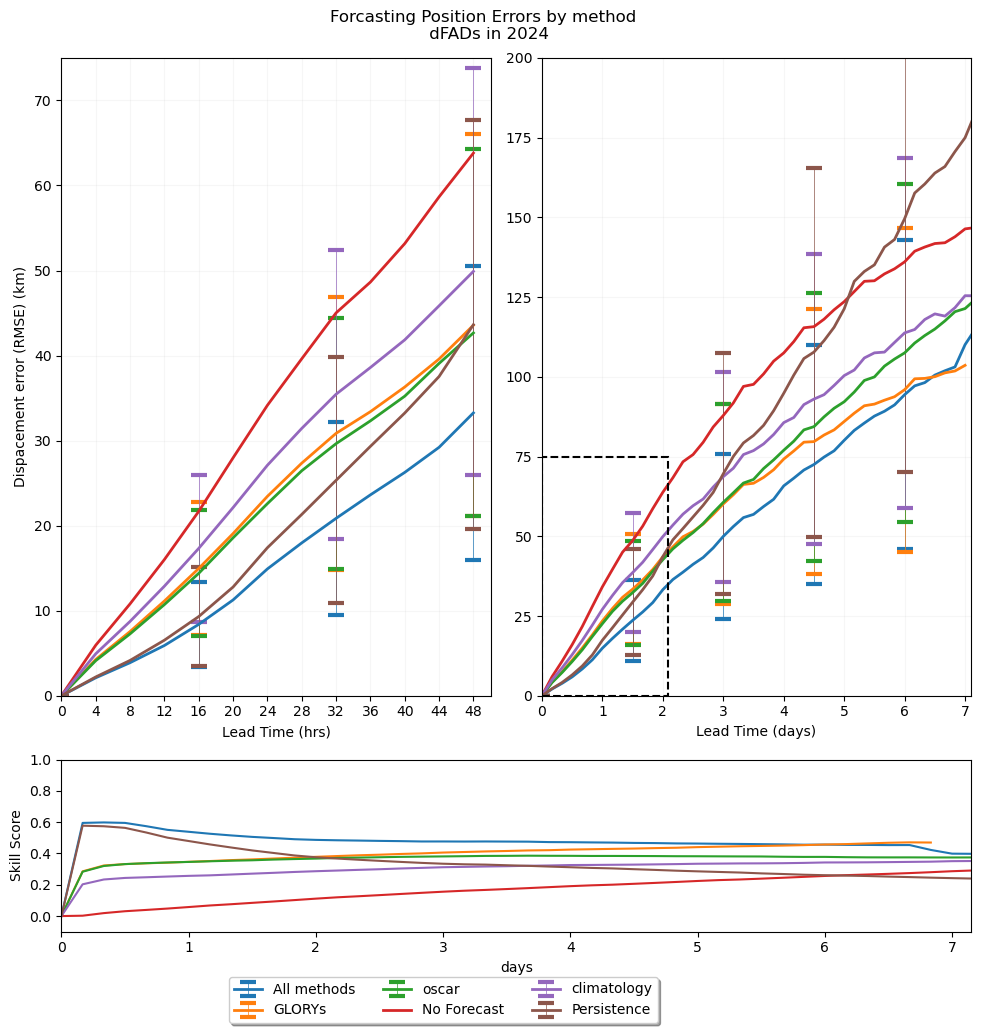

In [138]:
from matplotlib.patches import ConnectionPatch

fig = plt.figure(figsize=(10,10))
gs = gridspec.GridSpec(3, 2, width_ratios=[3,3], height_ratios= [5,5,3])
labels = ['All methods','GLORYs', 'oscar', 'No Forecast', 'climatology', 'Persistence' ]
colors = ['red', 'green', 'blue', 'k', 'orange', 'purple']
bins = np.linspace(0,8*24,2*24+1)
if skill_score == True: 
    ax0 = fig.add_subplot(gs[:2,0])
    ax1 = fig.add_subplot(gs[:2,1])
    ax2 = fig.add_subplot(gs[2,:])
    #ax3 = fig.add_subplot(gs[2,1])
else:     
    ax0 = fig.add_subplot(gs[:,0])
    ax1 = fig.add_subplot(gs[:,1])

for i in range(len(dslist)):
    yerr0 = stds[i][:13]
    yerr1 = stds[i][:]
    if labels[i] == 'No Forecast':
        yerr0 = None
        yerr1 =  None
    ax0.errorbar(bins[0:13], ltes[i][:13], lw = 2, yerr = yerr0, 
                 capsize = 6  , errorevery=4, elinewidth= 0.5, mew = 3)
    ax1.errorbar(bins[:]/24, ltes[i][:], lw =2, yerr = yerr1 , label = labels[i],  
                 capsize = 6  , errorevery=9, elinewidth= 0.5, mew = 3)
    if skill_score == True: 
        ax2.plot(bins[:]/24, sss[i])
        #ax3.plot(bins[:7], sss[i][:7])

#limits
ax0.set_xticks(np.linspace(0,52,14))
ax0.set_xlim(0,50)
ax0.set_ylim(0,75)
#ax0.set_ylim(0,150)
ax1.set_xlim(0,7.1)
ax1.set_ylim(0,200)
ax1.set_xticks(np.linspace(0,7,8))

ax0.set_ylabel("Dispacement error (RMSE) (km)")
ax0.set_xlabel("Lead Time (hrs)")
ax1.set_xlabel("Lead Time (days)")
ax0.grid(alpha = 0.1)
ax1.grid(alpha = 0.1)

# Draw on ax1 the same data-window shown in ax0 (ax0 x is hours, ax1 x is days)
x0_hr, x1_hr = ax0.get_xlim()
y0, y1 = ax0.get_ylim()

zoom_box = plt.Rectangle((x0_hr / 24.0, y0), (x1_hr - x0_hr) / 24.0, y1 - y0,
                         fill=False, edgecolor="black", linestyle="--", linewidth=1.5, zorder=10)
ax1.add_patch(zoom_box)
if skill_score == True:
    ax2.set(xlim = [0,7.15],ylim = [-0.1,1], ylabel = 'Skill Score', xlabel ='days')
    #ax3.set(xlim = [-1,25], ylim = [-0.1,1], ylabel = 'Skill Score', xlabel ='hours', xticks=np.linspace(0,24,7))

fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
          fancybox=True, shadow=True, ncol=3)
fig.suptitle("Forcasting Position Errors by method \n dFADs in 2024")
fig.set_facecolor("#FFFFFF")
fig.tight_layout()
#fig.savefig(r"C:\FATE\Figures\Winter_update_presentation\Leadtime_dynamical.png")

In [ ]:
## calculating Distributution of errors. 
bins_middle = (bins[:-1] + bins[1:])/2
bins_middle = bins_middle[bins_middle < 168]
quantiles = np.linspace(0.1,1, 10)
leadbins = ds.lead_bins.unique().sort_values()

df = pd.DataFrame({'lead_bins':leadbins})

q =0.5
for q in quantiles:
    q_list = ds.groupby('lead_bins', observed= False)['error_km'].quantile(q)
    q_list = q_list.to_frame().rename(columns = {'error_km':round(q,1)}).reset_index()
    df = df.merge(q_list)
df= df.round(3)
df['leadtime'] = np.array(bins_middle[:], dtype = int)
dff = df.set_index('leadtime').drop(columns = 'lead_bins')
dff.to_csv(r"..\Data\errors_quantile_leadtimes.csv")


In [ ]:
q = ds3.groupby("lead_bins", observed= False)['error_km'].quantile(.7)
leadtimes = bins[q.index.codes]
q = q.to_frame(name = "error_km")
q['leadtime'] = bins[:-1] + bins[1:]/2
q = q.reset_index(drop= True)
q.to_csv("Data\70thquantile_leadtimeerrors.csv")

In [ ]:
## Lets test what removing the worst 10% of points would like like

ds['starttime'] = pd.to_datetime(ds["Time"]) - pd.to_timedelta(ds.leadtime, unit="hours").dt.round("min")
a = ds.lead_bins.unique().sort_values()[18]
lt72 = ds.groupby("lead_bins").get_group(a)
maxe = lt72.error_km.quantile(.90)
ltmaxe = lt72[lt72.error_km > maxe]
bad = pd.MultiIndex.from_frame(ltmaxe[['BuoyID', 'starttime']].drop_duplicates())
ds_index  = pd.MultiIndex.from_frame(ds[['BuoyID', 'starttime']]).isin(bad)
ds6 = ds[~ds_index]
dsbad = ds[ds_index]

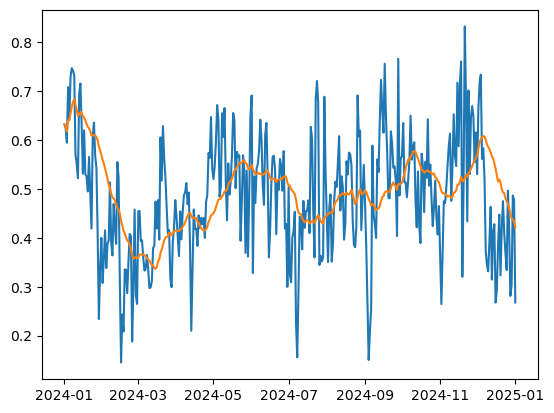

In [163]:
#Skill score analysis
df = dslist[0].copy()
# First look at skill score at a throughout a certain time 

#looking at skill scores at 3 days forecasts. 
leadbins = df.lead_bins.unique().sort_values()
tbin = leadbins[3*6]
dfh  =df.groupby('lead_bins', observed = False).get_group(tbin).copy()
dfh['startday'] = dfh.starttime.dt.date
dailyss = dfh.groupby('startday', observed = False)['skillscore'].mean().reset_index(level = 'startday')
dailyss['skill30day'] = dailyss['skillscore'].rolling(30, 1, center = False).mean()
fig , ax = plt.subplots()
ax.plot(dailyss.startday , dailyss.skillscore)
ax.plot(dailyss.startday , dailyss.skill30day)

### within one degree of Palmyra

In [ ]:
##filter for errors within 1 degree of palymra
import shapely 
palmyra = Palmyra_obj()

deg = 1
ds_1d = ds[ds["lat_true"] < palmyra.y+deg]
ds_1d = ds_1d[ds_1d["lat_true"] > palmyra.y-deg]
ds_1d = ds_1d[ds_1d["lon_true"] < palmyra.x +deg]
ds_1d = ds_1d[ds_1d["lon_true"] > palmyra.x - deg]
ds2_1d = ds2[ds2["lat_true"] < palmyra.y+deg]
ds2_1d = ds2_1d[ds2_1d["lat_true"] > palmyra.y-deg]
ds2_1d = ds2_1d[ds2_1d["lon_true"] < palmyra.x +deg]
ds2_1d = ds2_1d[ds2_1d["lon_true"] > palmyra.x - deg]

lte_1d = ds_1d.groupby("lead_bins", observed=False).apply(calculate_rmse, include_groups=False).to_numpy()
lte2_1d  = ds2_1d.groupby("lead_bins", observed=False).apply(calculate_rmse, include_groups=False).to_numpy()
std_1d = ds_1d.groupby("lead_bins", observed=False)["error_km"].std()
std2_1d = ds2_1d.groupby("lead_bins", observed=False)["error_km"].std()

pad = np.array([0])
lte_1d  = np.concat([pad,lte_1d])
pad = np.array([0])
lte2_1d = np.concat([pad,lte2_1d])
std_1d = np.concat([pad,std_1d])
std2_1d = np.concat([pad, std2_1d])

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (10,6))
ax[0].errorbar(bins[:]/24, lte_1d[:], yerr = std_1d, errorevery=6, capsize = 4, label = "kriging")
ax[0].errorbar(bins[:]/24, lte2_1d[:], yerr = std2_1d[:], errorevery=6, capsize = 4, label = "cmems")

ax[1].errorbar(bins[0:7], lte_1d[:7], yerr = std_1d[:7], capsize = 4)
ax[1].errorbar(bins[0:7], lte2_1d[:7], yerr = std2_1d[:7], capsize = 4)
ax[0].set_xticks(np.linspace(0,8,9))
ax[1].set_xticks(np.linspace(0,24,7))

ax[0].set_ylabel("error (km)")
ax[0].set_xlabel("lead time (days)")
ax[1].set_xlabel("lead time (hr)")


fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.05),
          fancybox=True, shadow=True, ncol=5)
fig.suptitle("Position Errors within 1 degree of Palmyra")

### Combining Drifter and dFAD data. 



In [ ]:
from functools import partial
pts = pd.read_csv("../Data/pts_changed.csv", low_memory=False)

pts['DateTime']=pd.to_datetime(pts['DateTime'], format='mixed')
pts['issuance_dt']=pd.to_datetime(pts['issuance_dt'], format='mixed')
 
 
# Compute lead time in case it is missing
if 'lead_time_hours_from_issuance' not in pts.columns:
    pts['lead_time_hours_from_issuance']=(
        pts['DateTime']-pts['issuance_dt']
    ).dt.total_seconds()/3600
 
# Lead time bins (0-168 hrs which is 7 days)
lead_time_bins=np.linspace(0,7*24,6*7+1)
pts['lead_bin']=pd.cut(
    pts['lead_time_hours_from_issuance'],
    bins=lead_time_bins
)
 
 
pts['error_forecast_km']=pts['error_forecast_m']/1000
pts['error_persistence_km']=pts['error_persistence_m']/1000
 
def calculate_rmse(group, model):
    rmse = np.sqrt((group[f"error_{model}_km"]**2).mean())
    return rmse
 
# Restrict to box around Palmyra
lon_mask= (pts['Longitude_true'] > 196.17) & (pts['Longitude_true'] < 199.584)
lat_mask=(pts['Latitude_true'] > 4.4166) & (pts['Latitude_true'] < 7.83)
pts=pts[lon_mask & lat_mask]
 
std_f=pts.groupby('lead_bin')['error_forecast_km'].std()
std_p=pts.groupby('lead_bin')['error_persistence_km'].std()
rmse_f=pts.groupby('lead_bin').apply(partial(calculate_rmse, model='forecast'),include_groups=False).to_numpy()
rmse_p=pts.groupby('lead_bin').apply(partial(calculate_rmse, model='persistence'),include_groups=False).to_numpy()
lte_f=rmse_f
lte_p=rmse_p

pad = np.array([0])
lte_f = np.concat([pad, lte_f])
lte_p = np.concat([pad, lte_p])

print(lte.shape)
print(len(lead_time_bins))
fig, ax = plt.subplots(1,2, figsize = (12,6))
ax[0].plot(lead_time_bins[:]/24, lte_f[:],  label = "Drifter - CMEMS"  , color = "firebrick")
ax[0].plot(lead_time_bins[:]/24, lte_p[:],  label = "Drifter - Persistence", color = "firebrick", linestyle = "--",)
ax[0].plot(bins[:-6]/24, lte2[:-6],  label = "dFADs - CMEMS", color = "cornflowerblue")
ax[0].plot(bins[:-6]/24, lte3[:-6], label = "dFADs - Persistence", color = "cornflowerblue", linestyle = "--")
 
 
ax[1].plot(lead_time_bins[0:7], lte_f[0:7], color = "firebrick")
ax[1].plot(lead_time_bins[0:7], lte_p[0:7], color = "firebrick",  linestyle = "--")
ax[1].plot(bins[0:7], lte2[:7], color = "cornflowerblue")
ax[1].plot(bins[0:7], lte3[:7], color = "cornflowerblue", linestyle = "--")
# ax[0].set_xticks(np.linspace(0,8,9))
# ax[1].set_xticks(np.linspace(0,24,7))
ax[0].set_xticks(np.linspace(0,7,8))
ax[1].set_xticks(np.linspace(0,24,7))
ax[0].set_ylabel("Error (km)")
ax[0].set_xlabel("Lead Time (days)")
ax[1].set_xlabel("Lead Time (hrs)")


 
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0),
          fancybox=True, shadow=True, ncol=5)
fig.suptitle("Position Errors dFADs vs Drifters \n within 3 degrees of Palymra")
fig.set_facecolor("#FFFDF6")
print(np.nanmean((lte_f[:]/ lte2[:-6])/(lte_f[:])))
print(lte_p[6])
print(lte3[6])


 

In [ ]:
fig = plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(1, 3, width_ratios=[3,3,1])

ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax_stats = fig.add_subplot(gs[0,2])
ax_stats.axis("off")


#ax0.errorbar(bins[:]/24, lte[:], yerr = std, errorevery=6, capsize = 4, label = "kriging")
ax0.errorbar(bins[:]/24, lte2[:], yerr = std2[:], errorevery=6, capsize = 4, label = "cmems")
ax0.errorbar(bins[:]/24, lte3[:], yerr = std3[:], errorevery = 6, capsize = 4, label = "Persistence")


ax1.errorbar(bins[0:7], lte[:7], yerr = std[:7], capsize = 4)
ax1.errorbar(bins[0:7], lte2[:7], yerr = std2[:7], capsize = 4)
ax1.errorbar(bins[0:7], lte3[:7], yerr = std3[:7], capsize =4 )
ax0.set_xticks(np.linspace(0,8,9))
ax1.set_xticks(np.linspace(0,24,7))

ax0.set_ylabel("error (km)")
ax0.set_xlabel("lead time (days)")
ax1.set_xlabel("lead time (hr)")
ax0.grid(alpha = 0.1)
ax1.grid(alpha = 0.1)


fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
          fancybox=True, shadow=True, ncol=5)
fig.suptitle("Forcasting Position Errors \n dFADs in 2024 ")
fig.set_facecolor("#FFFDF6")
fig.tight_layout()
fig.savefig(r"C:\FATE\Figures\Leadtime_drifter_vs_cmems.png")

### Corrilation between errors

In [ ]:
corrs = {}

for b in ds["lead_bins"].cat.categories:   # iterate over all bins
    e1 = ds.loc[ds["lead_bins"] == b, "error_km"]
    e2 = ds2.loc[ds2["lead_bins"] == b, "error_km"]

    # align lengths (optional — depends on your data structure)
    n = min(len(e1), len(e2))
    e1 = e1.iloc[:n]
    e2 = e2.iloc[:n]

    if n > 1:   # need at least 2 samples to compute correlation
        corr = np.corrcoef(e1, e2)[0, 1]
    else:
        corr = np.nan

    corrs[b] = corr

fig, ax = plt.subplots()
ax.plot(bins[0:-1], corrs.values()) 
print(corrs.keys())
print(bins)
print(corrs.values())
## think this is saying both models get errors the same after 4 hours, then theyre errors are uncorrilated. krigging gets it right or cmems? 

In [ ]:
### Plotting indivigual trajectories. 

def add_initial_time(ds): 
        
    ds["leadtime_td"] = pd.to_timedelta( ds["leadtime"], "hours")
    ds["Time"] = pd.to_datetime(ds["Time"])
    ds["initial_time"] = ds["Time"] - ds["leadtime_td"]
    ds["initial_time"] = ds["initial_time"].dt.round("h")
    return ds

ds = add_initial_time(ds)
ds1 = add_initial_time(ds2)
ds3 = add_initial_time(ds3)
ds4 = add_initial_time(ds4)
ds5 =  add_initial_time(ds5)


## Plotting indivigual tracks

In [ ]:
def drifter_forecast_plot(individual_csv, true_data,   datetime_column='DateTime'):
    df = individual_csv
    commid = df['BuoyID'].unique()
    df = df.rename(columns = {"Time": "DateTime"})
    true_data = true_data.rename(columns = {"Time": "DateTime"})
    df=df.sort_values('DateTime')
    true_data=true_data.sort_values('DateTime')
    #true_data = pd.read_csv(f'../individual_commID_data/cleaned_data_inconsistent_removed/new/cleaned_new_approach{commid}.csv')
 
    # Palmyra Atoll GPS coordinates
    pa_lat = 5.8900
    pa_lon = 197.9200- 360# adjusted by adding 360
 
    df.loc[:, datetime_column] = pd.to_datetime(df[datetime_column])
    true_data.loc[:, datetime_column] = pd.to_datetime(true_data[datetime_column])
    # Filter by week
    start_date = df[datetime_column].min()
    end_date = df[datetime_column].max()
 
    # Only get time of forecast
    timed_data = true_data[(true_data['DateTime'] >= start_date) & (true_data['DateTime']<=end_date)]
 
    #first_week_data = df[(df[datetime_column] >= start_date) & (df[datetime_column]<end_date)]
    timed_data  = timed_data.sort_values("DateTime")

 
    plt.figure(figsize=(20,10))
    plt.plot(pa_lon, pa_lat, 'ro', markersize=8, label='Palmyra Atoll')
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center right')
 
 
    plt.scatter(
        df['lon_forcast'],
        df['lat_forcast'],
        # hue=datetime_column,
        # palette='viridis',
        label='Forecasted Trajectory'
    )
    plt.plot(
        timed_data['lon_true'],
        timed_data['lat_true'],
        color='black',
        label='True Trajectory'
    )
    
    plt.annotate(
        f'Start Date: {start_date}',
        xy=(0.02, 0.98),
        xycoords='axes fraction',
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round, pad=0.2', fc='white', ec='black', lw=1, alpha=0.7)
    )
 
    plt.annotate(
        f'End Date: {end_date}',
        xy=(0.98, 0.98),
        xycoords='axes fraction',
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round, pad=0.2', fc='white', ec='black', lw=1, alpha=0.7)
    )
    
 
    plt.title(f'Scatter Plot of Latitude vs. Longitude of CommId: {commid} Forecast vs True')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(f'../forecast_plots/comparison_plots/comparison_commID_{commid}_forecast_vs_true.png')

In [ ]:
dFADs = gpd.read_parquet(r"..\Data\Mappedwinds_OSCAR_SAT_MI_Cleanedspeeds.parquet") 
def True_dFAD_data(ds, buoyID):
    """Turns one dFAD into a DataFrame"""
    Truedata = ds.query("BuoyName == @buoyID").reset_index(drop = True)
    x,y= Truedata.at[0,"geometry"].xy
    time = Truedata.at[0,"TimeStamp"]
    Truedata = pd.DataFrame({"DateTime":time, "lat_true": y, "lon_true": x})
    Truedata.DateTime = pd.to_datetime(Truedata.DateTime)
    return Truedata

def Add_bathymetry(fig,ax,cbar = True):
    from matplotlib import colormaps 
    bath = xr.open_dataset(r"..\Data\bath.nc")
    #bath_cmap = cm.get_cmap("Blues_r").copy()
    bath_cmap = colormaps['Blues_r']
    bath_cmap.set_over('green')
    negative_levels = np.linspace(-10000, 0, 11)
    cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"], 
                     cmap = bath_cmap, alpha = 0.8, levels = negative_levels, extend = "max")
    if cbar == True:
        fig.colorbar(cbr)
    cbr.set_label("m/s")
    return fig, ax

def plot_collectionzone(ax): 
    import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_circle_km(ax, radius_km=5, **patch_kwargs):
    from matplotlib.patches import Circle
    point = Palmyra_obj()
    circle = Circle(
        (point.x, point.y),
        radius_km,
        fill=False, 
        alpha = 0.75,
        **patch_kwargs
    )
    ax.add_patch(circle)
    return ax

def set_palmyra_lims(ax):
    ax.set_xlim(-163.6, -160.7)
    ax.set_ylim(4.5,7.7)
    return ax

In [ ]:
IDs = ds.BuoyID.unique()
print(len(IDs))
buoyID ="SLX+465699"

Truedata = True_dFAD_data(dFADs, buoyID)

perplot = ds.query("BuoyID == @buoyID ") ##SLX+487116 #10 had loops ##16 weird points ##119 ##hit palyra SLX+463917
#truedata = perplot.query("leadtime == 0 ")
drifter_forecast_plot(perplot, true_data=Truedata, datetime_column="DateTime")

In [ ]:
from functions import funcs
## Merging the true dFAD data onto forecasts 
longlist = pd.DataFrame({})
longlist["Time"] = funcs.Column_to_List(dFADs, "TimeStamp", idlist = False)
longlist["lats"], longlist["lons"] = funcs.list_of_latlon(dFADs, False)
longlist["x_speed"] = funcs.Column_to_List(dFADs, "x_speed", idlist = False)
longlist["y_speed"] = funcs.Column_to_List(dFADs, "y_speed", idlist = False)
longlist["v_mapped"], longlist["BuoyID"]  =funcs.Column_to_List(dFADs, "mapped_v", idlist = True)
longlist["v_mapped_OSCAR"], longlist["BuoyID"]  =funcs.Column_to_List(dFADs, "mapped_v_oscar", idlist = True)
longlist["u_mapped"] = funcs.Column_to_List(dFADs, "mapped_u", idlist = False)
longlist["u_mapped_OSCAR"] = funcs.Column_to_List(dFADs, "mapped_u_oscar", idlist = False)
longlist.Time = pd.to_datetime(longlist.Time)
def merge_forecast_true(fc, longlist):
    merged = pd.merge_asof(
    fc.sort_values('Time'),
    longlist.sort_values('Time'),
    on='Time',
    by='BuoyID',
    tolerance=pd.Timedelta(minutes=1),
    direction='nearest'
    )
    return merged

merged = merge_forecast_true(ds2, longlist)
merged["speed"] = np.sqrt(merged.x_speed**2 + merged.y_speed**2)
merged["starttime"] = (merged.Time - pd.to_timedelta(merged.leadtime, "hours")).dt.round('min')
merged = merged.sort_values(['starttime', 'Time']).reset_index(drop = True)

def calc_intial_speed_dif(merged, sufix= None):
    initial_speed_dif_mag = "initial_speed_dif_mag" 
    speed_dif_mag = "speed_dif_mag"
    u = "u_mapped"
    v = "v_mapped"
    if sufix is not None:
        initial_speed_dif_mag +=sufix
        speed_dif_mag +=sufix
        u += sufix
        v+= sufix 
    merged[speed_dif_mag] = np.sqrt((merged.x_speed - merged[u])**2 + (merged.y_speed - merged[v])**2)
    merged[initial_speed_dif_mag] = merged.groupby(["BuoyID", "starttime"],  observed=False)[speed_dif_mag].transform("first")
    return merged
merged_oscar = merged.query('best_model == "OSCAR"')
merged_cmems = merged.query('best_model == "cmems"')
merged_oscar = calc_intial_speed_dif(merged_oscar, "_OSCAR")
merged_cmems= calc_intial_speed_dif(merged_cmems)
merged_oscar = merged_oscar.rename(columns = {"initial_speed_dif_mag_OSCAR" : "initial_speed_dif_mag"})
merged = pd.concat([merged_oscar, merged_cmems])
merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)
def calc_iniial_lat(merged):
    merged = merged.sort_values("leadtime").reset_index(drop = True)
    merged["initial_lat"] = merged.groupby(["BuoyID", 'starttime'])["lat_true"].transform("first")
    return merged
merged = calc_iniial_lat(merged)
merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)

In [ ]:
def draw_forecast_cone(treudata, Forecast, q, ax): 
    """True data is all the true data within the window that is going to be plotted 
    Forecast is the one particle forecast 
    q is dataframe of uncurtainities to be plotted with collumns"""
    ## methos is to use a shapely object and then plot that. 
    ## start by making a circle at the last point
    Forecast = Forecast.sort_values("leadtime").reset_index(drop = True)

    ## now do this for all previous points and take the outside
    circles = []
    for n in range(len(Forecast)):
        poi = sp.Point( Forecast.iloc[n]['lon_forcast'], Forecast.iloc[n]['lat_forcast'])
        time = Forecast.iloc[n]['leadtime']
        maxid = (q.leadtime - time).abs().idxmin()
        r = q.error_km[maxid]
        circle = poi.buffer(r/111)
        circles.append(circle)

    poly = sp.union_all(circles)
    if poly.geom_type == "MultiPolygon":
        for p in poly.geoms:
            x,y = p.exterior.xy
            ax.plot(x,y, color = "r")
            ax.fill(x,y, color = 'r', alpha= 0.1, zorder = 100)
            ax.set_clip_path
    else:
        x,y = poly.exterior.xy
        ax.plot(x,y, color = "r")
        ax.fill(x,y, color = 'r', alpha= 0.1, zorder = 100)
    return ax


from shapely.geometry import LineString, Point
from matplotlib.path import Path
def draw_forecast_cone_dynamic(truedata, Forecast, q, ax, res=200, cmap=plt.cm.YlOrRd):
    Forecast = Forecast.sort_values("leadtime").reset_index(drop=True)
    
    Forecastlast = Forecast.tail(1).reset_index(drop = True) 

    # build shapely circles and union (your existing logic)
    circles = []
    for n in range(len(Forecast)):
        poi = Point(Forecast.iloc[n]['lon_forcast'], Forecast.iloc[n]['lat_forcast'])
        time = Forecast.iloc[n]['leadtime']
        r = q.sel(leadtime = time, q = 0.9, method = 'nearest').qsolved.values ## could draw other circles too or maybe still draw cone and just do shading 
        circles.append(poi.buffer(r / 111.0))
    poly = sp.union_all(circles)

    # bounds for the raster
    minx, miny, maxx, maxy = poly.bounds
    xs = np.linspace(minx, maxx, res)
    ys = np.linspace(miny, maxy, res)
    xv, yv = np.meshgrid(xs, ys)
    pts = np.column_stack([xv.ravel(), yv.ravel()])

    # use only the last forecast point
    px, py = Forecastlast.iloc[0][['lon_forcast', 'lat_forcast']]

    # raster points already built as `pts` (P,2)
    dists = np.hypot(pts[:, 0] - px, pts[:, 1] - py).reshape(res, res)

    # radius for last point (km -> degrees) and guard against zero
    r90 = float(q.sel(leadtime=Forecastlast.leadtime[0], q=0.9, method='nearest').qsolved.values)
    r_deg = r90 / 111.0
    if r_deg <= 0:
        alpha = np.zeros((res, res))
    else:
        alpha = np.clip(1.0 - dists / r_deg, 0.0, 1.0)

    # tweak contrast if desired
    alpha = alpha**0.8

    # build RGBA image from colormap and use alpha channel
    rgba = cmap(alpha)
    rgba[..., -1] = alpha

    # mask outside union polygon(s) (reuse your Path mask code)
    mask = np.zeros(alpha.shape, dtype=bool)
    polys = poly.geoms if poly.geom_type == "MultiPolygon" else [poly]
    for p in polys:
        path = Path(np.column_stack(p.exterior.xy))
        mask |= path.contains_points(pts).reshape(res, res)
    rgba[~mask] = (0, 0, 0, 0)

    ax.imshow(rgba, extent=(minx, maxx, miny, maxy), origin='lower', interpolation='bilinear', zorder=3)
    # redraw polygon outlines for clarity
        # build shapely circles and union (your existing logic)
    circles = []
    for n in range(len(Forecast)):
        poi = Point(Forecast.iloc[n]['lon_forcast'], Forecast.iloc[n]['lat_forcast'])
        time = Forecast.iloc[n]['leadtime']
        r = q.sel(leadtime = time, q = 0.7, method = 'nearest').qsolved.values ## could draw other circles too or maybe still draw cone and just do shading 
        circles.append(poi.buffer(r / 111.0))
    poly = sp.union_all(circles)
    if poly.geom_type == "MultiPolygon":
        for p in poly.geoms:
            x, y = p.exterior.xy
            ax.plot(x, y, color="r", lw=0.8)
    else:
        x, y = poly.exterior.xy
        ax.plot(x, y, color="r", lw=0.8)
    return ax

    """Right now this has calc just max distance and does ration of 0,1 but really, i want this to do max """

In [ ]:
qdata = xr.open_dataset(r'..\Data\regression_quantiles_leadtimes.nc')
qdata['leadtime'] = (qdata.leadtime + 1)*4

#qdata['qsolved'] = qdata.initial_lat*ilat + qdata.initial_speed_dif_mag*isd + qdata.Intercept

q70 = qdata.sel(q= 0.7, method ='nearest')

In [ ]:
def interp_ds(ds,dt_hours = 0.5, forecastds = True):
    newlt = np.arange(min(ds.leadtime), max(ds.leadtime)+0.001, 0.5)
    newlt = np.append(newlt, ds.leadtime)
    newlt = np.sort(newlt)
    newlt = np.unique(newlt)
    ds = ds.set_index('leadtime')
    ds = ds[~ds.index.duplicated()]
    ds = ds.reindex(newlt)
    if forecastds == True:
        ds['lon_forcast'] = ds['lon_forcast'].interpolate(method = 'linear')
        ds['lat_forcast'] = ds['lat_forcast'].interpolate(method = 'linear')
        # ds['lon_forcast'] = ds['lon_forcast'].interpolate(method = 'spline', order=1)
        # ds['lat_forcast'] = ds['lat_forcast'].interpolate(method = 'spline',order=1 )
    else:
        ds['lon_true'] = ds['lon_true'].interpolate(method = 'linear')
        ds['lat_true'] = ds['lat_true'].interpolate(method = 'linear')
        # ds['lon_true'] = ds['lon_true'].interpolate(method = 'spline', order=1)
        # ds['lat_true'] = ds['lat_true'].interpolate(method = 'spline', order=1)
    ds = ds.reset_index(names = 'leadtime')
    return ds

    

In [ ]:
##plotting one track 
### Give it one dFAD, one point, and all three forcasts 
def plot_Forcasts(BuoyID:str, dFAD_data, dsforcast: list,startday: int, labels: list, 
                  fig, ax, q:np.array, forcastlength = pd.Timedelta(days= 2), 
                  pastTrajectory = pd.Timedelta(days = 3), shaded_cone = False): ## could add getting startime and just get nearest point from that.
    ## getting true data
    perplot = dsforcast[0].query("BuoyID == @BuoyID ") 
    ##SLX+487116 #10 had loops ##16 weird points ##119 ##hit palyra SLX+463917
    truedata = True_dFAD_data(dFAD_data, BuoyID)
    forcasttimes = perplot.query("leadtime == 0 ").reset_index(drop= True)
    starttime_not_rounded = forcasttimes.at[startday, "Time"]
    starttime = pd.to_datetime(starttime_not_rounded)
    starttime = starttime.round('h')
    truedata['leadtime'] = truedata.DateTime - pd.to_datetime(starttime_not_rounded)
    truedata['leadtime'] = truedata.leadtime.dt.total_seconds()/3600
    truedata = interp_ds(truedata, forecastds= False)
    truedata['DateTime'] = starttime_not_rounded + pd.to_timedelta(truedata.leadtime, unit='hours')
    truedata = truedata[truedata.DateTime < (starttime + forcastlength)]
    truedata = truedata[truedata.DateTime > (starttime - pastTrajectory)]
    ##set x and y lims 
    #fig, ax = plt.subplots(figsize = (6,6))
    forcastlengthhr = forcastlength.total_seconds()/3600
    ax.plot(truedata.lon_true, truedata.lat_true, label = "dFAD Trajectory", lw= 1.5, color = "k", zorder = 6)
    colors = ["limegreen", "orange", "firebrick", "orange","limegreen"]
    ##Get forcast from that starttime 
    for i,ds in enumerate(dsforcast):
        ds = ds.query(f"BuoyID == @BuoyID")
        ds = ds.query(f"initial_time == @starttime").reset_index(drop = True)
        ds = interp_ds(ds)
        ds = ds.query('leadtime <= @forcastlengthhr').reset_index(drop = True)
        if len(ds)== 0:
            print('len is 0')
        starty =  ds.at[0,"lat_true"]
        startx =  ds.at[0,"lon_true"]
        ax.plot(ds.lon_forcast, ds.lat_forcast, label= labels[i], alpha = 0.75, color = colors[i] ,zorder =6)
        if shaded_cone == False:
            ax = draw_forecast_cone(truedata, ds, q, ax)
        else: 
            ax = draw_forecast_cone_dynamic(truedata,ds,q,ax)
    deg = 0.5
    #ax.set_ylim([starty -deg, starty +deg+0.2])
    #ax.set_xlim([startx -deg, startx+deg])
    ax.plot(startx, starty, color = "k", lw = 10, alpha= 1,zorder =7 )
    ax.set_title(f"Forecasts of dFAD \n{BuoyID} \n{starttime}")
    return fig, ax

merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)
IDs = merged.BuoyID.unique()
## Selecting what dFAd and forecast to plot

buoyID = IDs[447]
sd = 1
#getting intial angle and speed to solve error
Forecast = merged.query(f"BuoyID == @buoyID")
startdays = Forecast.query(f'leadtime == 0').reset_index(drop = True)
startday = startdays.at[sd,'Time'].round('h')
Forecast = Forecast.query(f'initial_time == @startday').reset_index(drop= True)
leadtimes = np.arange(Forecast.leadtime.min(), Forecast.leadtime.max(), 0.5)
isd = Forecast.initial_speed_dif_mag[0]
ilat = Forecast.initial_lat[0]
print(ilat, isd)
leadtimes = leadtimes[1:]
## solving Q
qs = qdata.copy()
qs = qs.interp(leadtime = leadtimes, kwargs={"fill_value": "extrapolate"})
qs['qsolved'] = qs.initial_lat*ilat + qs.initial_speed_dif_mag*isd + qs.Intercept

#Truedata = True_dFAD_data(dFADs, buoyID)
fig, ax = plt.subplots()
fig, ax = plot_Forcasts(buoyID, dFADs, [merged], startday = sd, labels = ["Forecast"], 
                        fig= fig, ax = ax, q=qs, forcastlength= pd.Timedelta(days = 7), 
                        pastTrajectory = pd.Timedelta(days = 7), shaded_cone=True) 
ax.legend()  
#ax = Palmyra_plot(ax)
fig, ax = Add_bathymetry(fig, ax)
ax.set_aspect("equal")
ax = plot_circle_km(ax, radius_km= 0.0833)
ax.set(xlim = [-163.75, -160.66], ylim = [ 4.5,7.75])
#fig.savefig("Forecasts_SLX+463917_3.png")
fig.set_facecolor("#FFFDF6")
fig.tight_layout()


In [ ]:
import matplotlib.animation as animation
from matplotlib.ticker import MultipleLocator

merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)
IDs = merged.BuoyID.unique()
## Selecting what dFAd and forecast to plot

buoyID = IDs[447]
sd = 1
#getting intial angle and speed to solve error
Forecast = merged.query(f"BuoyID == @buoyID")
startdays = Forecast.query(f'leadtime == 0').reset_index(drop = True)
startday = startdays.at[sd,'Time'].round('h')
Forecast = Forecast.query(f'initial_time == @startday').reset_index(drop= True)
isd = Forecast.initial_speed_dif_mag[0]
ilat = Forecast.initial_lat[0]
print(ilat, isd)
leadtimes = np.arange(Forecast.leadtime.min(), Forecast.leadtime.max()+0.001, 0.5)
#leadtimes = Forecast.leadtime
leadtimes = leadtimes[1:] ## get rid of zero 
## solving Q
qs = qdata.copy()
qs = qs.interp(leadtime = leadtimes, kwargs={"fill_value": "extrapolate"})
qs['qsolved'] = qs.initial_lat*ilat + qs.initial_speed_dif_mag*isd + qs.Intercept


ds['ledatime'] = pd.to_timedelta(ds.leadtime, 'hours')
## new calc a column of leatimes and error_km

fig, ax = plt.subplots(figsize=(6,6))

def update(hours):
    ax.clear()  # remove previous frame drawings
    # draw forecasts for this many days
    plot_Forcasts(
        buoyID, dFADs, [merged], startday=sd,
        labels=["Forecast"],
        fig=fig, ax=ax,q= qs,
        forcastlength=pd.Timedelta(hours=hours),
        pastTrajectory=pd.Timedelta(days=7), shaded_cone= True
    )
    try:
        ax.legend( loc="upper right", bbox_to_anchor=(1,0.98), bbox_transform=ax.transAxes)
    except Exception:
        pass
    Add_bathymetry(fig, ax, cbar = False)
    ax.set_aspect("equal")
    ax.text(0.75, 0.82, f"Days:{hours/24 :.2f}", bbox=dict(facecolor='white', alpha=0.5), transform=ax.transAxes)
    plot_circle_km(ax, radius_km=0.0833)
    startzoom = 2*24
    endzoom = 3.5*24
    xlim_s = np.array([-163.25+0.25, -161.75+0.25])
    ylim_s = np.array([ 5,6.5])
    xlim_e = np.array([-163.25+0.25, -160.75+0.25])
    ylim_e = np.array([ 4.5,7])
    dxlim = xlim_e - xlim_s
    dylim = ylim_e - ylim_s
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    if hours < 2*24: 
        ax.set(xlim = xlim_s, ylim =ylim_s)
    elif hours < endzoom: 
        ratio = (hours -startzoom)/(endzoom- startzoom)
        ax.set(xlim = xlim_s + dxlim*ratio, ylim = ylim_s + dylim*ratio)
    else:
        ax.set(xlim = xlim_e, ylim = ylim_e)

ani = animation.FuncAnimation(fig, update, frames=leadtimes, interval=100, blit=False)
ani.save(r"..\..\Figures\Animations\Forecast_cone.mp4", writer= 'ffmpeg')

In [ ]:
qs.qsolved

In [ ]:
import matplotlib.animation as animation
## create animation 
IDs = ds3.BuoyID.unique()
buoyID  = IDs[113]
fig, ax = plt.subplots()
def update(days):
    fig, ax = plot_Forcasts(buoyID, dFADs, [ds3], startday = 0, labels = ["Dynamical", "static"], fig= fig, ax = ax, forcastlength= pd.Timedelta(days = days), pastTrajectory = pd.Timedelta(days = 7)) 


ani = animation.FuncAnimation(fig, update, frames =7, interval = 500, blit = False)
ani.save("Forecast_cone.mp4", writer= 'ffmpeg')

In [ ]:
## testing drawing cones

In [ ]:
buoyID = "M3i+133729" 
IDs = dsbad.BuoyID.unique()
buoyID = IDs[18] ##Simple one 428427
if False: 
        
    for id in range(len(IDs)):
        buoyID = IDs[id]
        Truedata = True_dFAD_data(dFADs, buoyID)
        fig, ax = plt.subplots()
        days = dsbad.query('BuoyID == @buoyID')['starttime'].unique().shape[0]
        for i in range(days):
            fig, ax = plot_Forcasts(buoyID, dFADs, [dsbad], startday = i,
                                    labels = ["Dynamical", "static"], fig= fig, ax = ax,
                                    pastTrajectory = pd.Timedelta(days = 7), ) 

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())
        fig, ax = Add_bathymetry(fig, ax)
        ax.set_aspect("equal")
        ax = plot_circle_km(ax, radius_km= 0.0833)
        ax = set_palmyra_lims(ax)
        fig.set_facecolor("#FFFDF6")
        fig.savefig(fr"..\..\Figures\Bad_Forecasts\{buoyID}.jpg")


In [ ]:
dFADs = distance_from_Palymra(dFADs)
dFADs = dFADs.sort_values("distance_km")
dFADs2024 = dFADs[dFADs["MinOfDate"] > pd.to_datetime("2024-1-1")]
dFADs2024 = dFADs2024[dFADs2024["MinOfDate"] < pd.to_datetime("2025-1-1")]
dFADs2024 = dFADs2024.reset_index(drop = True)
ngps = len(Column_to_List(dFADs2024,"TimeStamp"))
print(ngps)

dFADs_5km = dFADs[dFADs.distance_km < 11.12] ##6 nautical miles
print(len(dFADs_5km))
print(dFADs.MinOfDate.min(), dFADs.MaxOfDate.max())
(ngps*(1/111**2)*4/24/365)*24*24
print(len(dFADs))
#print(dFADs.query("BuoyName == 'SLX+480197'"))
dFADs2024.iloc[120]

In [ ]:
fig, ax = plt.subplots()
ax.hist(dFADs['MaxOfDate'], bins = 4*12)
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel("start Dates of dFADs ")
ax.set_title("number of new dFADs")